# Example QNN to be used in this project

In [1]:
# Thread Limiting (prevent kernel crashes on some Linux)
import os

# Limit threads to P-cores only (i9-13900K: 8 Performance cores)
os.environ["OMP_NUM_THREADS"] = "8"
os.environ["MKL_NUM_THREADS"] = "8"
os.environ["TORCH_NUM_THREADS"] = "8"

# Intel-specific thread pinning
os.environ["KMP_AFFINITY"] = "granularity=fine,compact,1,0"

In [2]:
import numpy as np
import sys
import os
import time
import itertools
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm.notebook import tqdm

project_root = os.path.abspath('../..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)
print(f'Project root: {project_root}')

# Import project modules
from src.datagen import mackey_glass, generate_arma_data, generate_narma_data
from src.datagen import split_and_scale_series
from src.models_batch import draw_circuit, gqnn_shape, gqnn
from utils.Charts import multi_plot_flat_ts, meas_plot

Project root: /home/jacob/Dropbox/Dev/Python/quantum_projects/qtsa_expressivity


In [3]:
import pennylane as qml
from pennylane import numpy as np
import torch

In [4]:
### Constants
SEED = 2025
TRAIN_FRACTION = 0.7
FIGURES_DIR = Path('../reports') # Results will be saved in the data folder
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Device definition

In [5]:
### My device related constants
sim = 'lightning.qubit' # 'lightning.qubit' # 'default.qubit' #
interface = 'autograd'  # 'torch' # 
diff_method = 'adjoint' # 'parameter-shift' # 'adjoint' # 'backprop' # as we use QRC and no training # 
level='gradient'
shots = None

### Find what devices are available

# Type to be used with tensors
dtype = torch.float64
torch.set_default_dtype(dtype)

# Enable CUDA device if available
torch_device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f'\nThe optimum devices: {sim} and {torch_device}')

# Force CPU to avoid moving computation and data back and from the GPU
torch_device = "cpu"

print(f'Devices to be used:  {sim} and {torch_device}\n')


The optimum devices: lightning.qubit and cpu
Devices to be used:  lightning.qubit and cpu



## Generate data

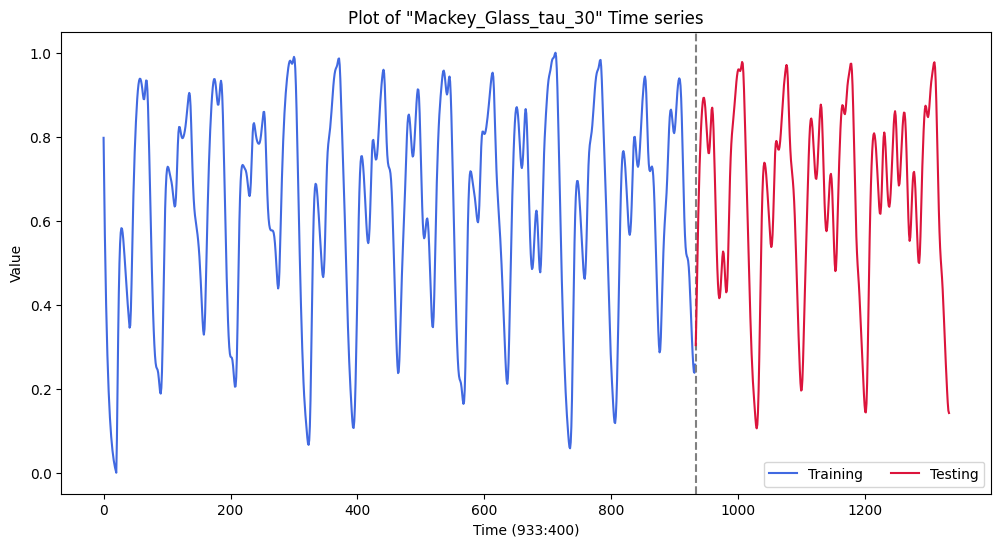

In [6]:
### Generate and plot the Mackey-Glass time series
time_series_mg30 = mackey_glass(tau=30)
chart_name_mg30 = 'Mackey_Glass_tau_30'

# PLot this time series
y_temp_train, y_temp_test, _ = split_and_scale_series(time_series_mg30, TRAIN_FRACTION)
train_size, test_size = len(y_temp_train), len(y_temp_test)
x_temp_train = list(range(train_size))
x_temp_test = list(range(train_size, train_size+test_size))
multi_plot_flat_ts(
    [x_temp_train, x_temp_test], [y_temp_train, y_temp_test],
    dpi=100, rcParams=(12, 6), vert_lines=['', 'dashed'], vert_line_color='gray', 
    colors=['royalblue', 'crimson'], lines=['solid', 'solid'],
    xlabel=f'Time ({train_size}:{test_size})', ylabel='Value',
    labels=['Training', 'Testing'], title=f'Plot of "{chart_name_mg30}" Time series',
    save_plot=FIGURES_DIR / f'xfig_series_{chart_name_mg30}.png')

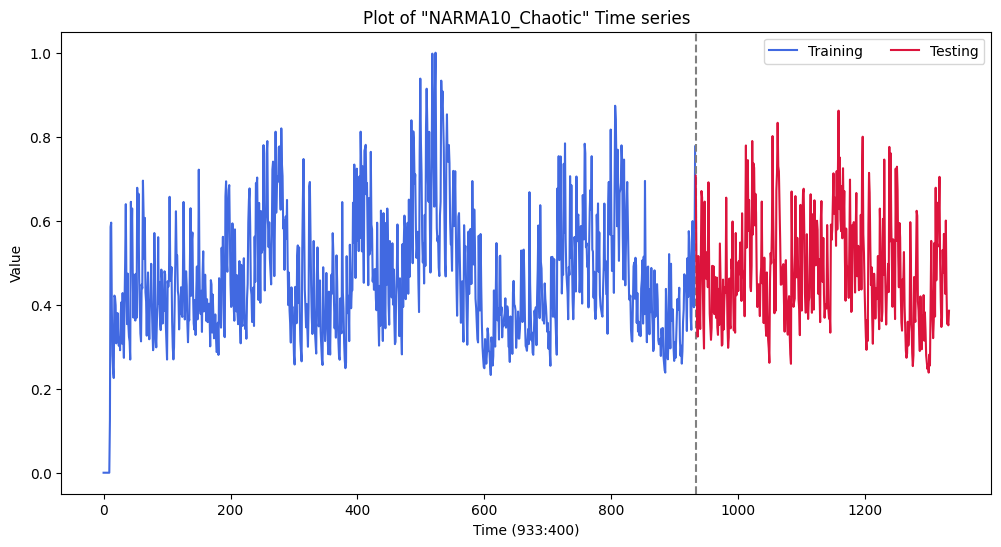

In [7]:
### Generate and plot NARMA10 time series
time_series_narma10 = generate_narma_data(order=10)
chart_name_narma10 = 'NARMA10_Chaotic'

# PLot this time series
y_temp_train, y_temp_test, _ = split_and_scale_series(time_series_narma10, TRAIN_FRACTION)
train_size, test_size = len(y_temp_train), len(y_temp_test)
x_temp_train = list(range(train_size))
x_temp_test = list(range(train_size, train_size+test_size))
multi_plot_flat_ts(
    [x_temp_train, x_temp_test], [y_temp_train, y_temp_test],
    dpi=100, rcParams=(12, 6), vert_lines=['', 'dashed'], vert_line_color='gray', 
    colors=['royalblue', 'crimson'], lines=['solid', 'solid'],
    xlabel=f'Time ({train_size}:{test_size})', ylabel='Value',
    labels=['Training', 'Testing'], title=f'Plot of "{chart_name_narma10}" Time series',
    save_plot=FIGURES_DIR / f'xfig_series_{chart_name_narma10}.png')

### Select one of the data sets

In [8]:
time_series = time_series_narma10
chart_name = chart_name_narma10

### Prepare time series partitions

In [9]:
### Prepare the data, scale to [0..1]
def create_io_pairs(data, window_size):
    """
    Create input-output pairs for training/testing.
    """
    inputs = []
    outputs = []
    for i in range(len(data) - window_size):
        inputs.append(data[i:i + window_size])
        outputs.append(data[i + window_size])
    return np.array(inputs, requires_grad=False), np.array(outputs, requires_grad=False)

### Data settings
window_size = 5    # 2 4 6 8
train_size = int(len(time_series) * TRAIN_FRACTION)
test_size =  len(time_series) - train_size

### Create data
train_inputs, train_outputs = create_io_pairs(time_series[:train_size], window_size)
test_inputs, test_outputs = create_io_pairs(time_series[train_size:train_size + test_size], window_size)

In [10]:
### Change the data format explicitly to tensors 
#   (not needed as by default they are correct and requires_grad=False)
train_inputs = qml.numpy.tensor(np.array(train_inputs), requires_grad=False)
train_outputs = qml.numpy.tensor(np.array(train_outputs), requires_grad=False)
test_inputs  = qml.numpy.tensor(np.array(test_inputs), requires_grad=False)
test_outputs  = qml.numpy.tensor(np.array(test_outputs), requires_grad=False)

## Model training and investigation

### Training utilities
*These cost functions assume the model is broadcasting (batches) its input parameters!*

In [11]:
### Our own gradient-friendly loss function
def mse_cost(targets, predictions):
    # Standard array operations keep the full gradient tape alive
    diff = targets - predictions
    cost = qml.math.mean(diff ** 2)
    return cost

### The cost function generator
def cost_fun_gen(model, cost_fun):
    def _cost_fun(params, inputs, targets):
        nonlocal model, cost_fun
        
        # 1. Capture the raw list or single array from the QNode
        raw_preds = model(inputs, params)
        # raw_preds = np.array([model(x, params) for x in inputs]) # No broadcasting
        
        # 2. Convert to a unified tensor safely
        # If it's a list of measurements, stack them vertically along axis=1
        if isinstance(raw_preds, list):
            preds = qml.math.stack(raw_preds, axis=1) # Shape: (batch_size, num_meas)
        else:
            preds = raw_preds # Shape: (batch_size,) if only 1 measurement
            
        # 3. Match the exact dimension layout of your targets
        # Flatten both to 1D to ensure the shapes match exactly
        preds_flat = qml.math.reshape(preds, -1)
        targets_flat = qml.math.reshape(targets, -1)
        
        return cost_fun(targets_flat, preds_flat)
    return _cost_fun

### Settings

In [12]:
##### Model settings for models with 1 input

### the circuit
#   Notes: 
#     Window can be larger than the number of qubits
#       in which case the window is left trimmed
#     Window can be smaller than the number of qubits
#       in which case extra qubits are added with params and CNOTs
n_qubits = window_size-2
n_inputs = window_size
n_layers = 3
fm_style = 'zzfm'
reup_style = 'X' # None, X, Y, Z

### training meta-params
epochs = 50           # Training epochs
shots = None          # Ignored for statevector
print_fract = 0.1     # Frequency of training reporting 
weights_scaler = 0.05 # Scales weights
seed = 2026

### device
dev = qml.device(sim, wires=n_qubits)

### Create a circuit to train

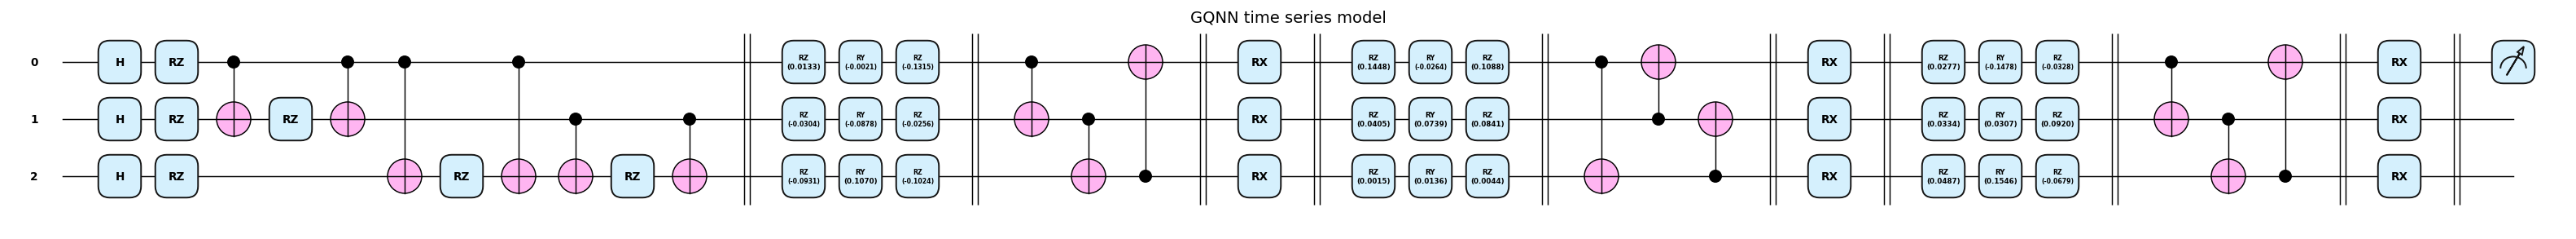

In [13]:
shape = gqnn_shape(n_layers, n_qubits)
circuit = gqnn(n_layers, n_qubits, dev,
    interface=interface, diff_method=diff_method, 
    fm_style=fm_style, reup_style = reup_style, meas=[0])

sample_inputs = train_inputs[100:101]
sample_weights = np.random.uniform(-np.pi, np.pi, shape, requires_grad=True)*weights_scaler

title = f'GQNN time series model'
draw_circuit(circuit, scale=0.7, title=title, decimals=4, level='user') \
    (sample_inputs, sample_weights) # also try level='device'

### Some tests

In [14]:
sample_inputs=train_inputs[100:105]
sample_inputs

tensor([[0.26945573, 0.45590931, 0.44277752, 0.45766702, 0.65695028],
        [0.45590931, 0.44277752, 0.45766702, 0.65695028, 0.49117814],
        [0.44277752, 0.45766702, 0.65695028, 0.49117814, 0.45663763],
        [0.45766702, 0.65695028, 0.49117814, 0.45663763, 0.48956529],
        [0.65695028, 0.49117814, 0.45663763, 0.48956529, 0.3597617 ]], requires_grad=False)

In [15]:
sample_outputs=train_outputs[100:105]
sample_outputs

tensor([0.49117814, 0.45663763, 0.48956529, 0.3597617 , 0.29880845], requires_grad=False)

In [16]:
### Apply the circuit to some data, observe what it returns
result = circuit(sample_inputs, sample_weights)
result

[array([0.08641476, 0.57027275, 0.58339379, 0.23614313, 0.50700025])]

In [17]:
### Calculate the cost
cost_fun = cost_fun_gen(circuit, mse_cost)
cost = cost_fun(sample_weights, sample_inputs, sample_outputs)
cost

tensor(0.0488351, requires_grad=True)

In [18]:
### Make the cost scalar
cost.item()

0.048835099020193395

### Training loop

In [19]:
### Set the random seed
np.random.seed(seed)

### Select one of the following optimisers built into PennyLane
# opt = qml.GradientDescentOptimizer(stepsize=0.5)
# opt = qml.RMSPropOptimizer(stepsize=0.1, decay=0.7, eps=1e-08)
# opt = qml.NesterovMomentumOptimizer(stepsize=0.5)
# opt = RCDOptimizer(h=0.1)
opt = qml.AdamOptimizer(stepsize=0.5)

### Define the cost function
cost_fun = cost_fun_gen(circuit, mse_cost)

### Initialise the model weights / parameters
weights = np.random.uniform(-np.pi, np.pi, shape, requires_grad=True)*weights_scaler

### Training loop
hist_cost = []
hist_weights = []
prompt_fract = 0.1
start_time = time.time() 
for iter in range(epochs):

    # 1. Create a 1-parameter execution target.
    # It reads train_inputs and train_outputs safely as static constants,
    # preventing PennyLane from touching or modifying their data shapes!
    # Lambdas will not work for batched data as python / autograd get confused
    def objective_fn(current_weights):
        return cost_fun(current_weights, train_inputs, train_outputs)
    
    # 2. Pass ONLY the objective function and weights into step_and_cost
    weights, cost = opt.step_and_cost(objective_fn, weights)

    # 3. Do the admin and print partial results
    hist_cost.append(cost.item())
    hist_weights.append(weights)
    elapsed_time = time.time()-start_time
    if (prompt_fract == 0) or (iter % int(prompt_fract*epochs) == 0):
        print(f'Iter: {iter:03d} ({int(elapsed_time):03d} sec) cost={np.round(cost, 6)}')

### Print the training summary
train_mse_hist = hist_cost
train_min_mse = np.min(train_mse_hist)
train_min_mse_iter = np.argmin(train_mse_hist)
print(f'\nTraining completed: epochs={epochs}, '+\
      f'min cost={np.round(train_min_mse, 6)} @ {train_min_mse_iter}, '+\
      f'time={int(elapsed_time):03d} secs\n')

Iter: 000 (001 sec) cost=0.207725
Iter: 005 (010 sec) cost=0.044862
Iter: 010 (019 sec) cost=0.043965
Iter: 015 (028 sec) cost=0.02351
Iter: 020 (036 sec) cost=0.022483
Iter: 025 (045 sec) cost=0.018733
Iter: 030 (054 sec) cost=0.018024
Iter: 035 (063 sec) cost=0.01502
Iter: 040 (072 sec) cost=0.015302
Iter: 045 (081 sec) cost=0.014234

Training completed: epochs=50, min cost=0.013602 @ 49, time=088 secs



### Plot the training curve

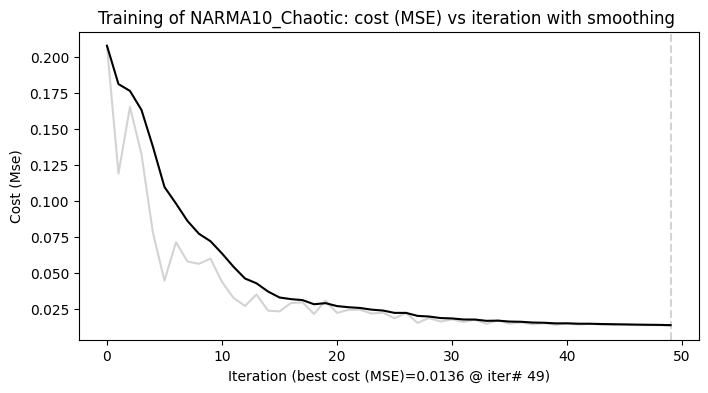

In [20]:
meas_plot(train_mse_hist, rcParams=(8, 4), task='min',
                  backplot=True, back_color='lightgray', smooth_weight=0.7,
                  meas='cost (MSE)', title_pref=f'Training of {chart_name}:')

## Systems in use (Linux)

In [21]:
!pip list | grep -e pennylane -e torch

pennylane                 0.45.0
pennylane_catalyst        0.15.0
pennylane_lightning       0.45.0
pennylane_lightning_gpu   0.45.0
torch                     2.11.0+cpu
torchaudio                2.11.0
torcheval                 0.0.7
torchmetrics              1.9.0
torchsummary              1.5.1
torchvision               0.26.0+cpu
